In [1]:
import time
start_time = time.perf_counter()

In [2]:
# import importlib
# from io import StringIO
from pathlib import Path

import chdb
from chdb import datastore as ds
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import my_modules.my_modules as mm

Default dirty pages decay period: 5000ms


In [3]:
%matplotlib inline

In [4]:
%%time
file = (Path(Path.cwd().parent) / "db/raw_data/cars_sales.csv").as_posix()
dsf = ds.DataStore.from_file(file) 

CPU times: user 194 µs, sys: 11 µs, total: 205 µs
Wall time: 171 µs


In [5]:
%%time
dsf.describe()

CPU times: user 2.06 s, sys: 954 ms, total: 3.02 s
Wall time: 2.01 s


,year,mileage,power,price
count,724644.000000,771799.000000,1.273353e+06,1.294757e+06
mean,2009.684535,154893.397115,1.415560e+02,1.444358e+06
std,9.367108,100738.336936,6.563943e+01,1.970257e+06
min,1936.000000,1000.000000,1.000000e+00,2.700000e+02
25%,2003.000000,82000.000000,9.800000e+01,4.250000e+05
50%,2011.000000,144000.000000,1.280000e+02,8.700000e+05
75%,2017.000000,211000.000000,1.630000e+02,1.765000e+06
max,2023.000000,1000000.000000,1.000000e+03,1.500000e+08


In [6]:
%%time
dsf_info = dsf.info()
dsf_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
  #   Column                Non-Null Count    Dtype  
 --  --------------------  ----------------  -----  
  0   brand                 1294757 non-null  object
  1   name                  1294757 non-null  object
  2   bodyType              1294757 non-null  object
  3   color                 1257029 non-null  object
  4   fuelType              1289815 non-null  object
  5   year                  724644 non-null   float64
  6   mileage               771799 non-null   float64
  7   transmission          1289563 non-null  object
  8   power                 1273353 non-null  float64
  9   price                 1294757 non-null  int64
 10   vehicleConfiguration  724647 non-null   object
 11   engineName            720976 non-null   object
 12   engineDisplacement    717625 non-null   object
 13   date                  1294757 non-null  datetime64[s]
 14   location              1

In [7]:
%%time
total_rows, total_null_val, types, table = mm.custom_info(dsf)
with pd.option_context(
    'display.expand_frame_repr', False,
):
    display(table)
    print(f"Всего записей: {total_rows}, Null значений: {total_null_val}, Типы данных: {types}")

,Column,Non-Null Count,Non-Null Count %,Null Count,Null Count %,Total Rows,Dtype
0,brand,1294757,100.000000,0,0.000000,1294757,object
1,name,1294757,100.000000,0,0.000000,1294757,object
2,bodyType,1294757,100.000000,0,0.000000,1294757,object
3,color,1257029,97.090000,37728,2.910000,1294757,object
4,fuelType,1289815,99.620000,4942,0.380000,1294757,object
5,year,724644,55.970000,570113,44.030000,1294757,float64
6,mileage,771799,59.610000,522958,40.390000,1294757,float64
7,transmission,1289563,99.600000,5194,0.400000,1294757,object
8,power,1273353,98.350000,21404,1.650000,1294757,float64
9,price,1294757,100.000000,0,0.000000,1294757,int64


Всего записей: 1294757, Null значений: 2923714, Типы данных: datetime64[s](2), float64(3), int64(1), object(12)
CPU times: user 4.48 s, sys: 4.02 s, total: 8.5 s
Wall time: 2.31 s


In [8]:
%%time

cl = dsf.columns.to_list()
cl.remove("link")
cl.remove("description")

dfs = []
sample_size_per_group = 10000  

for group_id in range(1, 4):  # группы 1, 2, 3
    query = f"""
    WITH ranked AS (
        SELECT {','.join(cl)}, NTILE(3) OVER (ORDER BY rand()) AS tile
        FROM file('{file}', 'CSV')
    )
    SELECT * FROM ranked
    WHERE tile = {group_id}
    ORDER BY rand()
    LIMIT {sample_size_per_group}
    """
    dfs.append(chdb.query(query, "DataFrame"))

CPU times: user 24 s, sys: 15.3 s, total: 39.4 s
Wall time: 10.4 s


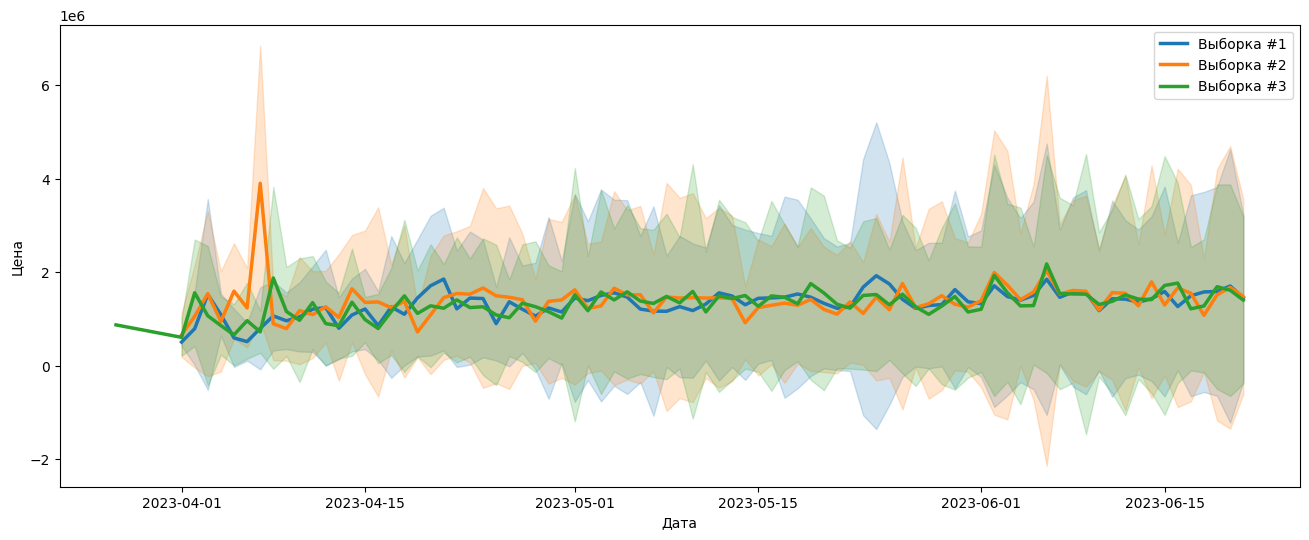

CPU times: user 387 ms, sys: 27 ms, total: 414 ms
Wall time: 459 ms


In [9]:
%%time
plt.figure(figsize=(16, 6))
for idx, df_number in enumerate(dfs, 1):
    sns.lineplot(x='date', y='price', data=df_number, linewidth=2.5, errorbar='sd', label=f"Выборка #{idx}")
plt.xlabel('Дата') 
plt.ylabel('Цена') 
plt.show()

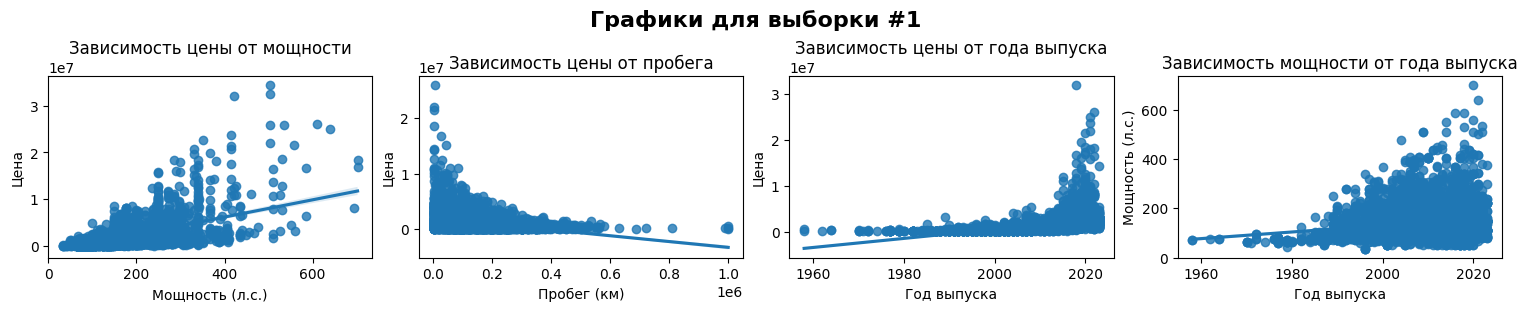

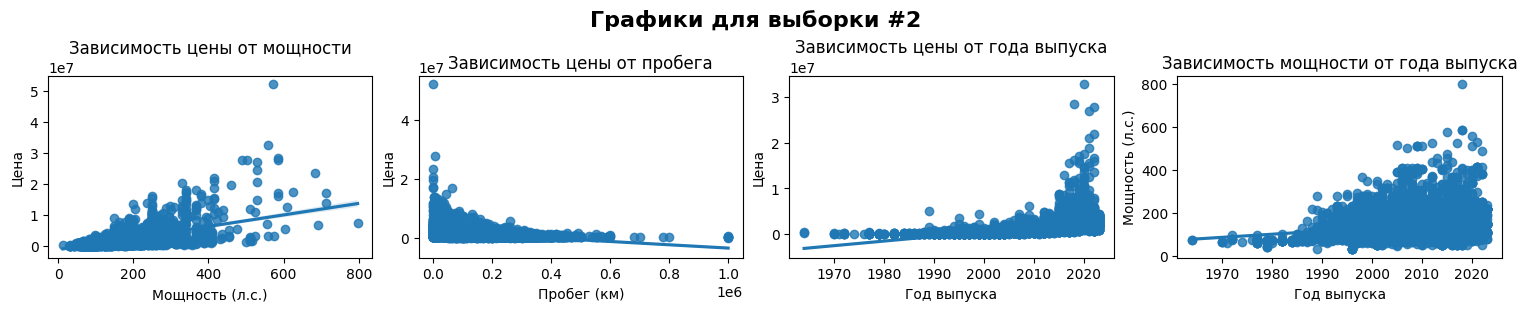

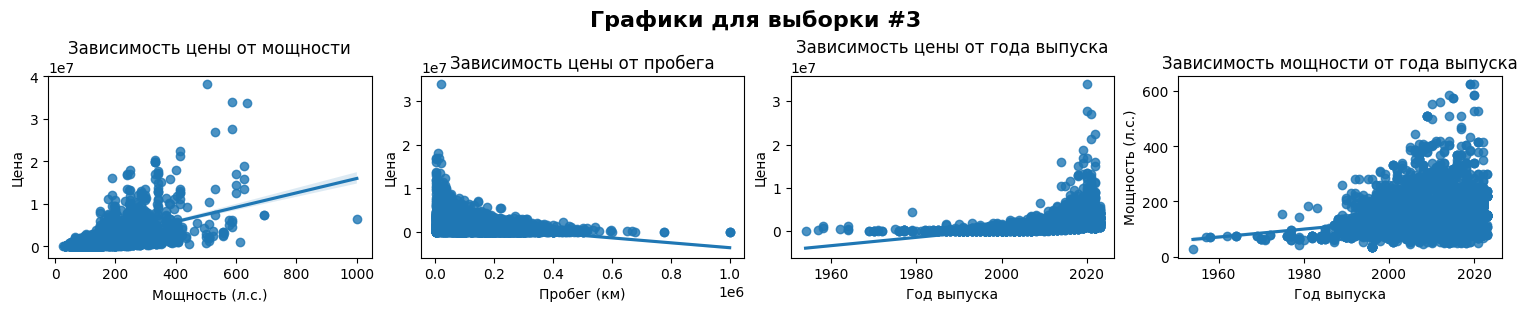

CPU times: user 4.29 s, sys: 35.8 ms, total: 4.32 s
Wall time: 4.3 s


In [10]:
%%time

for idx, df_number in enumerate(dfs):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), constrained_layout=True)
    fig.suptitle(f'Графики для выборки #{idx + 1}', fontsize=16, fontweight='bold')

    # График 1: power vs price
    sns.regplot(data=dfs[idx], x='power', y='price', ax=axes[0])
    axes[0].set_xlabel('Мощность (л.с.)')
    axes[0].set_ylabel('Цена')
    axes[0].set_title('Зависимость цены от мощности')

    # График 2: mileage vs price
    sns.regplot(data=dfs[idx], x='mileage', y='price', ax=axes[1])
    axes[1].set_xlabel('Пробег (км)')
    axes[1].set_ylabel('Цена')
    axes[1].set_title('Зависимость цены от пробега')

    # График 3: year vs price
    sns.regplot(data=dfs[idx], x='year', y='price', ax=axes[2])
    axes[2].set_xlabel('Год выпуска')
    axes[2].set_ylabel('Цена')
    axes[2].set_title('Зависимость цены от года выпуска')

    # График 4: year vs power
    sns.regplot(data=dfs[idx], x='year', y='power', ax=axes[3])
    axes[3].set_xlabel('Год выпуска')
    axes[3].set_ylabel('Мощность (л.с.)')
    axes[3].set_title('Зависимость мощности от года выпуска')

plt.show()


In [11]:
end_time = time.perf_counter()
total_time = end_time - start_time
print(f"Общее время выполнения: {total_time:.4f} секунд")

Общее время выполнения: 23.4947 секунд
